# 03 - Sentiment Analysis & Feature Engineering

This notebook processes the cleaned review data to extract sentiment-based features, which are critical for detecting fake reviews.


## 1. Import Libraries and Load Data


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from textblob import TextBlob
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk

# Ensure VADER lexicon is downloaded
nltk.download("vader_lexicon", quiet=True)

sns.set(style="whitegrid")


In [2]:
# Load the cleaned data from stage 2
input_path = os.path.join("..", "data", "stage2_cleaned_data.csv")
if os.path.exists(input_path):
    df = pd.read_csv(input_path)
    print(f"Loaded {len(df)} reviews.")
else:
    print(f"File not found: {input_path}")
df.head()


Loaded 69737 reviews.


,review_id,user_name,review_text,rating,helpful_votes,app_version,review_date,developer_reply,app_name,review_length,hour,cleaned_review,review_len,word_count
0,016bbd04-7f9c-4c2b-8f82-8d7cab4f424f,Sean Harris,"always happy with their service and goods,just...",5,0,32.4.0.100,2026-03-11 18:25:22,NaN,Amazon Shopping,97,18,"always happy with their service and goods,just...",97,18
1,7a6f39b1-5534-4eed-8100-1cdbedc5ea1e,Finn Fiechtner,pros and cons. 3 star review dead center. cons...,3,0,NaN,2026-03-11 18:15:01,NaN,Amazon Shopping,484,18,pros and cons. 3 star review dead center. cons...,484,82
2,967d3ed1-6855-493d-8816-d7434a22180c,Bassam Yousre,the worst delivery service ever always not on ...,1,0,32.5.0.100,2026-03-11 18:08:16,NaN,Amazon Shopping,141,18,the worst delivery service ever always not on ...,141,26
3,9767efd5-66d8-4dc8-a86f-2c2a26bd0ee4,SO SUPO,happy,4,0,32.5.0.100,2026-03-11 17:57:29,NaN,Amazon Shopping,5,17,happy,5,1
4,26cf286d-c77c-4c64-ba92-dbb119a510fe,Steve Day,Says my phone is not compatible with tap to pa...,1,0,32.5.0.100,2026-03-11 16:45:46,NaN,Amazon Shopping,278,16,says my phone is not compatible with tap to pa...,278,51


## 2. Text Preprocessing for Sentiment
We already cleaned the text in stage 2, but we will ensure it is in string format for the analyzers.


In [3]:
df["review_text"] = df["review_text"].astype(str)

def get_textblob_sentiment(text):
    return TextBlob(text).sentiment.polarity

print("Calculating TextBlob sentiment...")
df["textblob_sentiment"] = df["review_text"].apply(get_textblob_sentiment)


Calculating TextBlob sentiment...


## 3. VADER Sentiment Integration
VADER is particularly good for social media and review text (it understands punctuation like "!!!" and capitalization like "GREAT").


In [4]:
sid = SentimentIntensityAnalyzer()

def get_vader_sentiment(text):
    return sid.polarity_scores(text)["compound"]

print("Calculating VADER sentiment...")
df["vader_sentiment"] = df["review_text"].apply(get_vader_sentiment)


Calculating VADER sentiment...


## 4. Sentiment-Rating Inconsistency
Fake reviews often have a mismatch between the text sentiment and the numerical rating (e.g., 1 star with positive text).


In [5]:
# Normalize rating to 0-1 scale to compare with sentiment
# (Rating - 1) / (5 - 1) maps 1->0 and 5->1
df["norm_rating"] = (df["rating"] - 1) / 4

# Sentiment is -1 to 1, we want 0 to 1 for comparison
df["norm_sentiment"] = (df["vader_sentiment"] + 1) / 2

# Calculate absolute difference between rating and sentiment
df["sentiment_inconsistency"] = abs(df["norm_rating"] - df["norm_sentiment"])

print("Calculated sentiment-rating inconsistency.")


Calculated sentiment-rating inconsistency.


## 5. Visualizing Inconsistencies


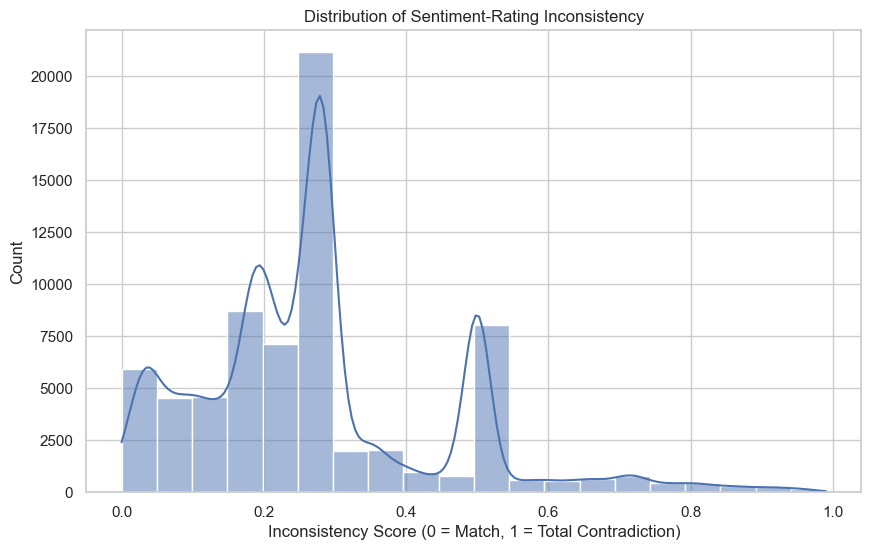

In [6]:
plt.figure(figsize=(10, 6))
sns.histplot(df["sentiment_inconsistency"], bins=20, kde=True)
plt.title("Distribution of Sentiment-Rating Inconsistency")
plt.xlabel("Inconsistency Score (0 = Match, 1 = Total Contradiction)")
plt.show()


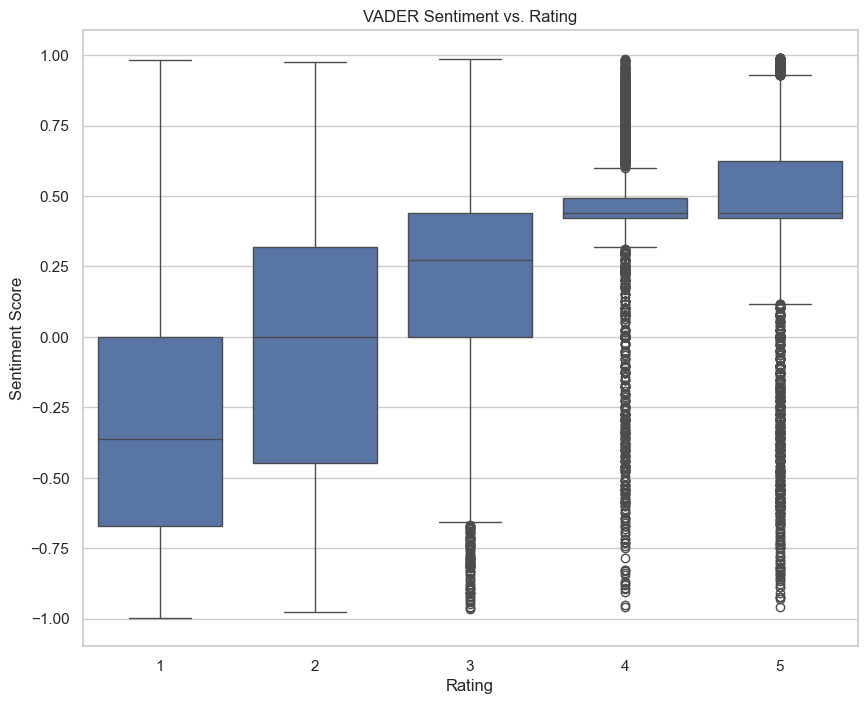

In [7]:
plt.figure(figsize=(10, 8))
sns.boxplot(x="rating", y="vader_sentiment", data=df)
plt.title("VADER Sentiment vs. Rating")
plt.xlabel("Rating")
plt.ylabel("Sentiment Score")
plt.show()


## 6. Exporting Features
We will save all the engineered features for the next stage (Detection Model).


In [8]:
output_path = os.path.join("..", "data", "stage3_features.csv")
df.to_csv(output_path, index=False)
print(f"Saved {len(df)} records with features to {output_path}")


Saved 69737 records with features to ..\data\stage3_features.csv
